# Training Pipeline

Training is configuration driven, with each experiment defined in a single TOML file.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import torch

## TOML configuration

In [2]:
config_path = Path("../configs/baseline.toml")
print(config_path.read_text())

seed = 42
run_name = "baseline"
output_dir = "models"

[data]
train_csv = "data/cbis-ddsm/training/train.csv"
val_csv = "data/cbis-ddsm/training/val.csv"
test_csv = "data/cbis-ddsm/training/test.csv"
image_root = "data/cbis-ddsm/cbis_ddsm"
image_size = 224

[model]
name = "baseline"
pretrained = false

[train]
batch_size = 32
early_stop_patience = 10



In [3]:
from src.config import load_config

config = load_config(config_path)
print(config)

Config(seed=42, run_name='baseline', data=DataConfig(train_csv=PosixPath('data/cbis-ddsm/training/train.csv'), val_csv=PosixPath('data/cbis-ddsm/training/val.csv'), test_csv=PosixPath('data/cbis-ddsm/training/test.csv'), image_root=PosixPath('data/cbis-ddsm/cbis_ddsm'), image_size=224, cache_dir=None), model=ModelConfig(name='baseline', pretrained=False, dropout_conv=0.3, dropout_head=0.5, head_hidden=256), train=TrainConfig(epochs=50, batch_size=32, lr=0.001, weight_decay=0.0, optimiser='adam', scheduler=None, early_stop_patience=10, stage1_epochs=5, stage2_lr=1e-05), output_dir=PosixPath('models'))


## Class-Weighted Loss

The dataset has more benign than malignant cases.

`BCEWithLogitsLoss` with `pos_weight = n_neg / n_pos` is used to rebalance the loss contribution.
`pos_weight` is computed from the training fold only, not the full dataset to avoid leakages.

In [4]:
from src.training.loss import make_criterion

train_csv = Path("../data/cbis-ddsm/training/train.csv")
df = pd.read_csv(train_csv)
n_pos = int((df["label"] == 1).sum())
n_neg = int((df["label"] == 0).sum())

print(f"Positive (malignant): {n_pos}")
print(f"Negative (benign): {n_neg}")
print()
print(f"pos_weight = {n_neg}/{n_pos} = {n_neg / n_pos:.3f}")

criterion = make_criterion(train_csv)
print(f"BCEWithLogitsLoss pos_weight = {criterion.pos_weight.item():.3f}")

Positive (malignant): 1062
Negative (benign): 1514

pos_weight = 1514/1062 = 1.426
BCEWithLogitsLoss pos_weight = 1.426


## Two-Stage Transfer Learning

For pretrained backbones, training happens in two stages:
1. Stage 1, freeze the backbone, train only the classification head at the config learning rate for `stage1_epochs` epochs.
2. Stage 2, unfreeze the top convolutional blocks, continue training at lower `stage2_lr` with a cosine scheduler.

This prevents the randomly initialised head from corrupting the pretrained features during early training.

In [5]:
from src.models import build_model
from src.models.transfer import freeze_backbone, unfreeze_head, unfreeze_top_blocks

model = build_model("vgg16", pretrained=False)

# Before freezing
trainable_before = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Stage 1: Freeze everything, unfreeze head
freeze_backbone(model)
unfreeze_head(model)
trainable_stage1 = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Stage 2: Unfreeze top blocks
unfreeze_top_blocks(model, "vgg16")
trainable_stage2 = sum(p.numel() for p in model.parameters() if p.requires_grad)

total = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total:,}")
print(f"Trainable parameters before freezing: {trainable_before:,}")
print(f"Trainable parameters after stage 1: {trainable_stage1:,}")
print(f"Trainable parameters after stage 2: {trainable_stage2:,}")

Total parameters: 135,309,633
Trainable parameters before freezing: 135,309,633
Trainable parameters after stage 1: 120,594,945
Trainable parameters after stage 2: 127,674,369


## Callbacks

Both callbacks gate on validation AUC, not validation loss. 
BCE correlates with AUC but not monotonically, the best-loss epoch is rarely the best AUC epoch.

In [6]:
from src.training.callbacks import EarlyStopping

# Simulate a few epochs of training with validation AUC scores
stopper = EarlyStopping(patience=3)
auc_values = [0.70, 0.75, 0.74, 0.73, 0.80, 0.79, 0.78, 0.77]

for epoch, auc in enumerate(auc_values):
    should_stop = stopper(auc)
    print(f"Epoch {epoch}: AUC = {auc:.2f}, best AUC = {stopper.best:.2f}")
    if should_stop:
        print(f"Stopping early at epoch {epoch}")
        break


Epoch 0: AUC = 0.70, best AUC = 0.70
Epoch 1: AUC = 0.75, best AUC = 0.75
Epoch 2: AUC = 0.74, best AUC = 0.75
Epoch 3: AUC = 0.73, best AUC = 0.75
Epoch 4: AUC = 0.80, best AUC = 0.80
Epoch 5: AUC = 0.79, best AUC = 0.80
Epoch 6: AUC = 0.78, best AUC = 0.80
Epoch 7: AUC = 0.77, best AUC = 0.80
Stopping early at epoch 7


## Learning Rate Schedulers

Two schedulers are supported:

* CosineAnnealingLR, smooth decay to zero, good for transfer learning.
* ReduceLROnPlateu, halves LR after 5 epochs without AUC improvement.

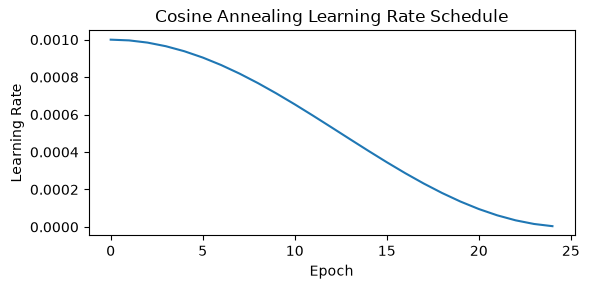

In [8]:
optimiser = torch.optim.Adam([torch.nn.Parameter(torch.zeros(1))], lr=0.001)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=25)

lrs = []
for _ in range(25):
    optimiser.step()
    lrs.append(scheduler.get_last_lr()[0])
    scheduler.step()

plt.figure(figsize=(6, 3))
plt.plot(lrs)
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Cosine Annealing Learning Rate Schedule")
plt.tight_layout()
plt.show()